In [7]:
import pandas as pd
import numpy as np
import optimization.optimization as opt
import matplotlib.pyplot as plt
import geopandas as gpd
import pydeck as pdk
pdk.settings.rendering = "iframe"

import optimization_plots
import importlib

importlib.reload(optimization_plots)
importlib.reload(opt)


climate_models = ['ICHEC-EC-EARTH', 'MPI-M-MPI-ESM-LR', 'NCC-NorESM1-M']
climate_scenarios = ['rcp26', 'rcp45', 'rcp85']
ILAND_MANAGEMENTS = ["high-structure", "low-structure", "medium-structure", "no-mgmt"]
ILAND_COLORS = [
    [255, 165, 0, 160],   # orange
    [50, 205, 50, 160],   # limegreen
    [0, 100, 0, 160],     # darkgreen
    [128, 0, 128, 160]    # purple
]
ES = ['abovegroundCarbon', 'shannonIndex', 'evapotranspiration_mm', 'mean_soilwatercontent_mm', 'volumeHarvested']
ID_VARS_ORIGINAL = ['rid', 'Germany_id', 'RCPScenario', 'Management']
ID_VARS_PIVOT = ['rid', 'Germany_id', 'RCPScenario', 'ES']

hexagons = gpd.read_file('hexagon_grid.shp').to_crs(epsg=4326)
germany_extent = [4, 17, 46, 56]

# Management Options

- no-mgmt,
- low-structure = Kahlschlag bzw. Schirmschlag je nachdem ob Laubholz- oder Nadelholz-dominiert
   - gepflanzt dann in gleichen zusammensetzungen wie initial
- medium-structure = Femelschlagverfahren (group selection)
    - an paar stellen löcher reinmachen, kleine gruppen von bäumen entnehmen (200-400m2), da dann pflanzen, in den nächsten Jahren werden die Löcher größer gemacht
        - der Lichtkegel wird immer größer
         - Hügellandschaft des Alters
- high-structure = Plenter (single tree selection)
    - Zielstärken
        - Plenterkurve, reverse J Kurve (viele dünne, weniger dicke, aber dauerhaft alle Durchmesser klassen vorhanden)
                -
                        -
Baumartenveraenderunge noch nicht.
        -

iland ist hier ohne spinup gelaufen, ginge aber theoretisch

Original data has 23232000 rows.

In [3]:
# reading takes 1.5min
iland_cluster6_chunks = pd.read_csv('cluster6_for_Konstantin_hexagon.csv.gz', chunksize=10000)
iland_cluster6 = pd.concat([chunk[(chunk['RCPScenario'] != 'historical') & (chunk['ClimateModel'] == climate_models[0]) & (chunk['Replicate'] == 'repl0')] for chunk in iland_cluster6_chunks])

# Optimize a dataframe with multiple GCs

In [16]:
iland_multiple_gc = iland_cluster6.copy()
iland_multiple_gc = iland_multiple_gc[iland_multiple_gc['decade'] == 8][['rid', 'Germany_id', 'RCPScenario', 'Management'] + ES]

In [17]:
df_long = iland_multiple_gc.melt(
    id_vars=ID_VARS_ORIGINAL,
    value_vars=ES,
    var_name="ES",
    value_name="value"
)

df_final = df_long.pivot_table(
    index=ID_VARS_PIVOT,
    columns="Management",
    values="value"
).reset_index().set_index(ID_VARS_PIVOT)

In [18]:
importlib.reload(opt)
iland_data_for_optimizer = df_final.groupby(['rid', 'Germany_id'], group_keys=False).apply(lambda grp: opt.prepare_for_optimization(grp, ['rid', 'Germany_id'], 'RCPScenario'))

In [25]:
iland_data_for_optimizer.to_csv('brandenburg_optimizer_data_normalized.csv')

# Optimization

In [3]:
iland_data_for_optimizer = pd.read_csv('brandenburg_optimizer_data_normalized.csv')#.set_index(['ES', 'Germany_id', 'rid', 'RCPScenario'])

In [68]:
importlib.reload(opt)
weights = [100.0, 1.0, 1.0, 1.0, 1.0]
optimized_data = iland_data_for_optimizer.reset_index().groupby(['rid', 'Germany_id'], group_keys=False).apply(lambda gc: opt.optimize_gridcell(gc, gc.name, location_names=['rid', 'Germany_id'], management_options=ILAND_MANAGEMENTS, climate_scenarios=climate_scenarios[0:1], es=ES, scenario_columnname='RCPScenario', es_columnname='ES', es_weights=weights))

/tmp/ipykernel_16243/30077863.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  optimized_data = iland_data_for_optimizer.reset_index().groupby(['rid', 'Germany_id'], group_keys=False).apply(lambda gc: opt.optimize_gridcell(gc, gc.name, location_names=['rid', 'Germany_id'], management_options=ILAND_MANAGEMENTS, climate_scenarios=climate_scenarios[0:1], es=ES, scenario_columnname='RCPScenario', es_columnname='ES', es_weights=weights))


In [69]:
# from joblib import Parallel, delayed
#
# importlib.reload(opt)
#
# groups = list(iland_data_for_optimizer.groupby(['rid', 'Germany_id']))
#
# def process_chunk(chunk):
#     out = []
#     for name, gc in chunk:
#         df = opt.optimize_gridcell(gc, name, location_names=['rid', 'Germany_id'], management_options=ILAND_MANAGEMENTS, climate_scenarios=climate_scenarios, es=ES, scenario_columnname='RCPScenario', es_columnname='ES', es_weights=weights)
#         df = df.copy()
#         df['rid'] = name[0]
#         df['Germany_id'] = name[1]
#         out.append(df)
#     return out
#
# chunk_size = 10  # tune this!
# # 1: 19s
# # 10: 22s
# # 20: 22s
# # 50: 22s
# # 100: 23s
# # 500: 24s
# chunks = [groups[i:i+chunk_size] for i in range(0, len(groups), chunk_size)]
#
# results = Parallel(n_jobs=-1)(
#     delayed(process_chunk)(chunk) for chunk in chunks
# )
#
# optimized_data = pd.DataFrame([s for sublist in results for s in sublist]).set_index(['rid', 'Germany_id'])

AssertionError: Optimization failed for gc (np.int64(390750102), np.int64(1162))

In [70]:
scores = iland_data_for_optimizer.set_index(['rid', 'Germany_id'])

cols = ['high-structure', 'low-structure', 'medium-structure', 'no-mgmt']

# --- Step 1: Merge datasets on rid + Germany_id ---
merged = scores.reset_index().merge(
    optimized_data.reset_index(),
    on=['rid', 'Germany_id'],
    suffixes=('_score', '_weight')
)

# --- Step 2: Compute weighted score (fast vectorized dot product) ---
score_vals = merged[[f"{c}_score" for c in cols]].values
weight_vals = merged[[f"{c}_weight" for c in cols]].values

merged['weighted_score'] = np.einsum('ij,ij->i', score_vals, weight_vals)

# --- Step 3: Aggregate per ES and RCPScenario (optional but usually needed) ---
result = (
    merged
    .groupby(['rid', 'Germany_id', 'RCPScenario', 'ES'], as_index=False)
    ['weighted_score']
    .sum()
)


In [71]:
mean_portfolios = optimized_data.groupby('Germany_id').apply(opt.compute_mean_portfolios)
mean_weighted_scores = result.groupby(['Germany_id', 'RCPScenario', 'ES'], as_index=False).mean()
min_scores = mean_weighted_scores.groupby(['Germany_id', 'ES'], as_index=False).min()
scores_wide = min_scores.pivot(
    index='Germany_id',
    columns='ES',
    values='weighted_score'
)
scores_wide.columns.name = None
result = mean_portfolios.join(scores_wide)

In [78]:
final_data = result.reset_index().merge(
    hexagons,
    on="Germany_id",
)
final_data["lon"] = final_data.geometry.apply(lambda x: x.representative_point().x)
final_data["lat"] = final_data.geometry.apply(lambda x: x.representative_point().y)

In [79]:
importlib.reload(optimization_plots)
optimization_plots.deck_plot(final_data, ILAND_MANAGEMENTS, ILAND_COLORS, es=ES)

{
  "initialViewState": {
    "latitude": 52.09672822222311,
    "longitude": 13.265655262010336,
    "zoom": 8
  },
  "layers": [
    {
      "@@type": "PolygonLayer",
      "autoHighlight": true,
      "data": [
        {
          "color": [
            255,
            165,
            0,
            160
          ],
          "name": "Portfolio",
          "polygon": [
            [
              11.332363832914963,
              52.246312027767544
            ],
            [
              11.405934609594869,
              52.246312027767544
            ],
            [
              11.400774818541759,
              52.26288399338023
            ],
            [
              11.332363832914963,
              52.246312027767544
            ]
          ],
          "slice": "high-structure",
          "value": 0.059961159404956055
        },
        {
          "color": [
            50,
            205,
            50,
            160
          ],
          "name": "Portfolio",
          "polygon": [
            [
              11.332363832914963,
              52.246312027767544
            ],
            [
              11.400774818541759,
              52.26288399338023
            ],
            [
              11.387644282370223,
              52.276035305542436
            ],
            [
              11.368040769343311,
              52.28570621747276
            ],
            [
              11.34425972183455,
              52.290764329024086
            ],
            [
              11.332363832914963,
              52.246312027767544
            ]
          ],
          "slice": "low-structure",
          "value": 0.16419110440432108
        },
        {
          "color": [
            0,
            100,
            0,
            160
          ],
          "name": "Portfolio",
          "polygon": [
            [
              11.332363832914963,
              52.246312027767544
            ],
            [
              11.34425972183455,
              52.290764329024086
            ],
            [
              11.320082147802976,
              52.29072498108061
            ],
            [
              11.297230977666727,
              52.28588909962076
            ],
            [
              11.332363832914963,
              52.246312027767544
            ]
          ],
          "slice": "medium-structure",
          "value": 0.10508312544391965
        },
        {
          "color": [
            128,
            0,
            128,
            160
          ],
          "name": "Portfolio",
          "polygon": [
            [
              11.332363832914963,
              52.246312027767544
            ],
            [
              11.297230977666727,
              52.28588909962076
            ],
            [
              11.283870731954291,
              52.280186996801035
            ],
            [
              11.272886731823581,
              52.27282496207549
            ],
            [
              11.264817212224791,
              52.264163747842765
            ],
            [
              11.260057593535528,
              52.254627768538
            ],
            [
              11.258841105280345,
              52.24468430359357
            ],
            [
              11.261227357481788,
              52.23482059994095
            ],
            [
              11.267099419666483,
              52.22551999607077
            ],
            [
              11.276169550660008,
              52.21723823761315
            ],
            [
              11.287993298400682,
              52.21038114501582
            ],
            [
              11.30199127885714,
              52.20528472764229
            ],
            [
              11.317477566845097,
              52.20219871873349
            ],
            [
              11.333693307544394,
              52.201274338048314
            ],
            [
              11.34984390169394,
              52.202556881

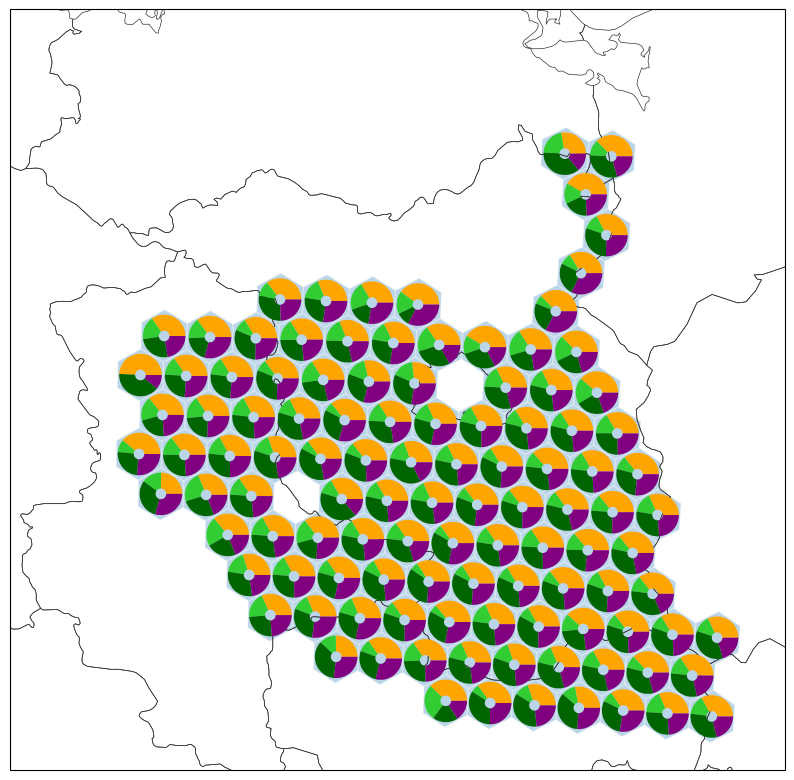

In [19]:
optimization_plots.plot_portfolios_on_hexagons(final_data, ILAND_MANAGEMENTS, ["orange", "limegreen", "darkgreen", "purple"])

In [20]:
final_data

,Germany_id,high-structure,low-structure,medium-structure,no-mgmt,geometry,lon,lat
0,1031,0.389207,0.096593,0.249731,0.264470,"POLYGON ((11.32927 52.14265, 11.18459 52.19608...",11.332364,52.246312
1,1032,0.491691,0.000000,0.399977,0.108332,"POLYGON ((11.3386 52.45391, 11.19292 52.50735,...",11.341754,52.557565
2,1056,0.248656,0.150903,0.308184,0.292257,"POLYGON ((11.4702 51.98529, 11.32619 52.03889,...",11.473606,52.088953
3,1057,0.358564,0.183387,0.217546,0.240502,"POLYGON ((11.48047 52.29654, 11.33547 52.35016...",11.483937,52.400199
4,1058,0.347171,0.176764,0.252497,0.223568,"POLYGON ((11.49092 52.60778, 11.34492 52.66141...",11.494448,52.711431
...,...,...,...,...,...,...,...,...
106,1652,0.315878,0.174303,0.270216,0.239604,"POLYGON ((14.73112 51.11975, 14.59369 51.17726...",14.741776,51.223197
107,1653,0.339059,0.105919,0.312772,0.242251,"POLYGON ((14.76325 51.43037, 14.62494 51.48791...",14.774083,51.533800
108,1678,0.344193,0.139343,0.302679,0.213786,"POLYGON ((14.89015 51.26914, 14.75248 51.32683...",14.901216,51.372563
109,1704,0.330268,0.148812,0.307878,0.213043,"POLYGON ((15.01619 51.10777, 14.87915 51.16561...",15.027487,51.211189


# TODOs for Johannes

- base values --> even for decade == 1 the values differ.
  - obwohl, vllt fuer historical scenario?
    - historical: einfach historisches Klima recycled.
        - damit könnte ich künstlich durchschnittswerte der baseline (dann low-structure nehmen, weil das halt das ist was in Brandenburg bisher gemacht wird)
            - oder BWI Daten
- was wurde validiert?
  - in Brandenburg ausser harvest, struktur, standing volume nicht evaluiert, nur in anderen iLand Studien
- other ESs
  - mitigation: substitution effects, koennte man die harvest pro baumart haben?  Ginge vllt
  - soil health?
  - local climate: ET, was noch?
  - C seq: braucht auch noch belowground!
- Wie sieht CO2 fertilization in iLand aus?
- shannonIndex: tree species oder tree hoehen?



iland - hat nur struktur, keine baumarten. Wieviel können wir nur durch strukturveränderung hinbekommen?

die zusammensetzung sollte immer

einzelbaumbasiert, wälder repräsentativ nach NFI
clearcut baumartenbasierte intervalle

shelterwood - even aged  (schirm)
umtriebszeit, oberbestand aufgelichtet gleichmässig, z.b. jede zweite, später dann verbliebenes Zeug
beim nadelwald will man aber gleich viel licht am boden haben





Vllt LPJ vs ILAND --> aehnliche Managementformen vielleicht.
dann vllt auf ganz deutschland ebene

retention trees wie high structure



